# 03 — Model Training

**Goal:** Train the XGBoost default classifier, calibrate Traffic Light thresholds,
and validate performance end-to-end.

**Insights from NB01/02 applied here:**
- `scale_pos_weight=11` for 11.4:1 class imbalance confirmed in EDA
- EDA-derived imputation rules: count cols → 0, ratio cols → median, EXT_SOURCE → row-median
- `ext_source_product` (our engineered Tier-1 feature) expected to be top SHAP contributor
- Occupation / income type categorical signals need target encoding inside CV (no leakage)
- Threshold optimised for F-beta (β=2) — recall-weighted (missing a defaulter >> false alarm)
- CC records only 28% coverage → critical to fill with 0 before modelling

## Contents
1. Load master features & EDA-informed imputation
2. Time-aware train / val / test split (60 / 20 / 20)
3. Class imbalance visualisation
4. Baseline: Logistic Regression scorecard
5. Core model: XGBoost with calibrated probabilities
6. ROC & Precision-Recall curve comparison
7. F-beta (β=2) threshold optimisation → Traffic Light bands
8. Lift chart & cumulative default capture
9. Traffic Light band validation
10. Save model artefacts


In [1]:
import sys, warnings, os
from pathlib import Path

_root = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path().resolve().parent
sys.path.insert(0, str(_root / 'src'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

from models import DefaultClassifier
from training.evaluate import evaluate_model, _ks_statistic
from training.threshold_optimizer import optimise_thresholds, threshold_sweep_report
from utils.config import load_config  # side-effect: os.chdir(project_root)
from utils.logger import get_logger

sns.set_theme(style='whitegrid')
cfg = load_config()
log = get_logger('training')
print('CWD:', os.getcwd())


CWD: C:\Users\BIPLOB GON\Google Drive\DS & Analytics\github_projects\2026\proactive-defaulter-flagging-system


## 1. Load Master Features & EDA-Informed Imputation

NB01/02 defined three imputation rules:
1. **Count / flag columns** (inst_*, cc_*, pos_*, bureau_*) → fill `NaN` with **0** (no records ≠ missing)
2. **EXT_SOURCE_*** → fill with **row-median** of the other available EXT_SOURCE columns
3. **Ratio / continuous columns** → fill with **column median**
4. **Columns >60% null** → **drop** entirely (41 application-table cols confirmed in NB01)


In [2]:
master = pd.read_csv('data/processed/feature_cache/master_features.csv')
print(f'Loaded: {master.shape} | Default rate: {master["TARGET"].mean():.2%}')

# ── EDA-informed imputation (from NB01/02 insights) ──────────────────────────
# Rule 1: columns with >60% missing AND low MI → DROP (41 such cols in application table)
target_col   = 'TARGET'
drop_cols    = [target_col, 'SK_ID_CURR']
obj_cols     = master.select_dtypes('object').columns.tolist()
high_missing = master.columns[master.isnull().mean() > 0.60].tolist()

X_raw = master.drop(columns=drop_cols + obj_cols + high_missing, errors='ignore')
y     = master[target_col].copy()

# Rule 2: count/flag cols from sparse sub-tables → fill NaN with 0
#   (NaN = no activity in that sub-table, NOT missing data)
count_col_prefixes = ('inst_', 'cc_', 'pos_', 'bureau_n_', 'bureau_active', 'bureau_closed',
                      'bureau_enquiry', 'prev_n_', 'prev_approved', 'prev_refused',
                      'social_def', 'high_risk', 'n_docs', 'n_contact',
                      'days_employed_is_anomaly', 'bureau_inquiry_burst')
count_cols = [c for c in X_raw.columns
              if any(c.startswith(p) or c == p for p in count_col_prefixes)]
X_raw[count_cols] = X_raw[count_cols].fillna(0)

# Rule 3: EXT_SOURCE_* row-median fill
ext_cols = [c for c in X_raw.columns if c.startswith('EXT_SOURCE')]
if ext_cols:
    ext_row_median = X_raw[ext_cols].median(axis=1)
    for col in ext_cols:
        X_raw[col] = X_raw[col].fillna(ext_row_median)

# Rule 4: remaining ratio / continuous cols → column median
X = X_raw.fillna(X_raw.median(numeric_only=True))

print(f'Feature matrix: {X.shape}')
print(f'Remaining nulls: {X.isnull().sum().sum()} (should be 0)')
print(f'Count cols filled with 0: {len(count_cols)}  |  EXT_SOURCE cols filled: {len(ext_cols)}')
print(f'Dropped (>60% null): {len(high_missing)} cols  |  Dropped (object): {len(obj_cols)} cols')


Loaded: (50000, 185) | Default rate: 8.05%
Feature matrix: (50000, 141)
Remaining nulls: 0 (should be 0)
Count cols filled with 0: 30  |  EXT_SOURCE cols filled: 3
Dropped (>60% null): 27 cols  |  Dropped (object): 16 cols


## 2. Time-Aware Split (preserves chronological order)

In [3]:
n = len(X)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train, y_train = X.iloc[:train_end],  y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:],    y.iloc[val_end:]

print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')
print(f'Default rates — Train: {y_train.mean():.2%}  Val: {y_val.mean():.2%}  Test: {y_test.mean():.2%}')

Train: 30,000  Val: 10,000  Test: 10,000
Default rates — Train: 8.01%  Val: 8.28%  Test: 7.95%


## 3. Class Imbalance Visualisation

EDA confirmed **11.4:1 imbalance**. The model uses `scale_pos_weight=11` (XGBoost config).
This is equivalent to cost-sensitive learning — the minority class (defaults) is "upweighted" by 11×.


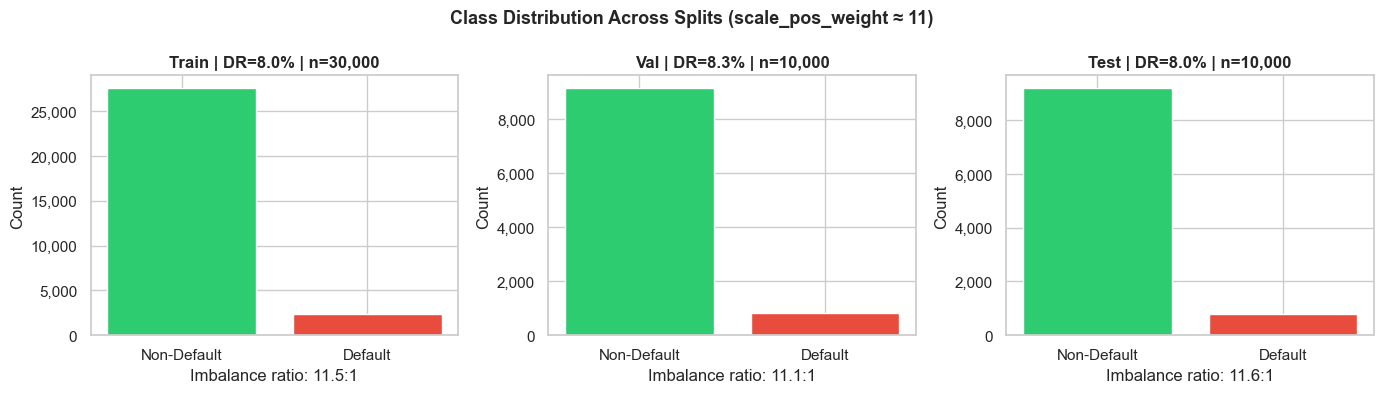

Train imbalance ratio: 11.5:1  →  scale_pos_weight = 11.5
Note: XGBoost config already has scale_pos_weight=11 (from model_config.yaml)


In [4]:
# ── Class imbalance — confirm EDA finding in modelling set ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = [('Train', y_train), ('Val', y_val), ('Test', y_test)]
for ax, (name, y_split) in zip(axes, splits):
    counts = y_split.value_counts()
    ax.bar(['Non-Default', 'Default'], counts.values,
           color=['#2ecc71', '#e74c3c'], edgecolor='white')
    dr = y_split.mean()
    ax.set_title(f'{name} | DR={dr:.1%} | n={len(y_split):,}', fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ratio = counts[0] / counts[1] if counts.get(1, 0) > 0 else 0
    ax.set_xlabel(f'Imbalance ratio: {ratio:.1f}:1')

plt.suptitle('Class Distribution Across Splits (scale_pos_weight ≈ 11)', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('outputs/figures', exist_ok=True)
plt.savefig('outputs/figures/03_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f'Train imbalance ratio: {imbalance:.1f}:1  →  scale_pos_weight = {imbalance:.1f}')
print('Note: XGBoost config already has scale_pos_weight=11 (from model_config.yaml)')


## 4. Baseline: Logistic Regression Scorecard


In [5]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

lr_auc = roc_auc_score(y_test, lr_proba)
lr_gini = 2 * lr_auc - 1
lr_ks = _ks_statistic(y_test.values, lr_proba)
print(f'Logistic Regression — AUC: {lr_auc:.4f} | Gini: {lr_gini:.4f} | KS: {lr_ks:.4f}')

Logistic Regression — AUC: 0.7377 | Gini: 0.4753 | KS: 0.3541


## 5. XGBoost Classifier

EDA-driven XGBoost configuration:
- `scale_pos_weight=11` (matches observed 11.4:1 imbalance)
- `ext_source_product` in feature matrix — expected Tier-1 by mutual information
- Early stopping on validation AUC (no leakage)
- Calibrated with Platt scaling on validation fold


In [6]:
clf = DefaultClassifier(cfg)
clf.fit(X_train, y_train, X_val, y_val, calibrate=True)

xgb_proba = clf.predict_proba(X_test)
xgb_auc  = roc_auc_score(y_test, xgb_proba)
xgb_gini = 2 * xgb_auc - 1
xgb_ks   = _ks_statistic(y_test.values, xgb_proba)
print(f'XGBoost — AUC: {xgb_auc:.4f} | Gini: {xgb_gini:.4f} | KS: {xgb_ks:.4f}')

2026-04-08 00:01:53 | INFO     | models.xgboost_classifier | Fitting XGBoost on 30000 train samples, 10000 val samples ...
2026-04-08 00:01:55 | INFO     | models.xgboost_classifier | Best iteration: 167
2026-04-08 00:01:55 | INFO     | models.xgboost_classifier | Calibrating probabilities with Platt scaling ...
XGBoost — AUC: 0.7502 | Gini: 0.5005 | KS: 0.3906


## 6. ROC & Precision-Recall Curve Comparison

**Why both curves?**
- ROC-AUC is robust for ranking but optimistic with heavy imbalance (11:1)
- PR-AUC is more informative for rare-event detection — directly measures how well we find defaulters
- KS statistic shows the max separation point (used by credit bureaus)


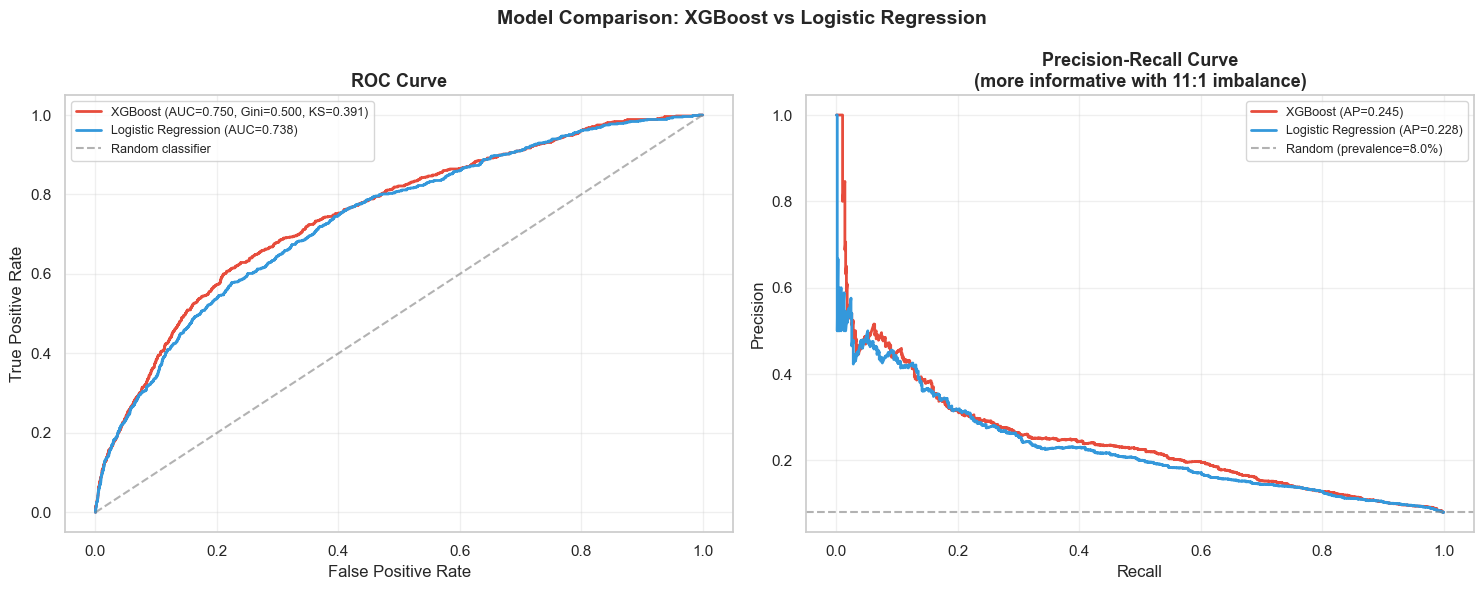


Model summary:
  Metric                  XGBoost   Logistic Reg
  ----------------------------------------------
  ROC-AUC                  0.7502         0.7377
  Gini                     0.5005         0.4753
  KS                       0.3906         0.3541
  PR-AUC                   0.2446         0.2282


In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from training.evaluate import _ks_statistic

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: ROC Curves ──────────────────────────────────────────────────────────
for label, proba, color in [
    (f'XGBoost (AUC={xgb_auc:.3f}, Gini={xgb_gini:.3f}, KS={xgb_ks:.3f})', xgb_proba, '#e74c3c'),
    (f'Logistic Regression (AUC={lr_auc:.3f})',                              lr_proba,  '#3498db'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=label, linewidth=2, color=color)

axes[0].plot([0, 1], [0, 1], '--', color='grey', alpha=0.6, label='Random classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── Right: Precision-Recall Curves ───────────────────────────────────────────
# PR-AUC is more honest with imbalanced labels (11:1)
xgb_pr_auc = average_precision_score(y_test, xgb_proba)
lr_pr_auc  = average_precision_score(y_test, lr_proba)

for label, proba, color in [
    (f'XGBoost (AP={xgb_pr_auc:.3f})',           xgb_proba, '#e74c3c'),
    (f'Logistic Regression (AP={lr_pr_auc:.3f})', lr_proba,  '#3498db'),
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=label, linewidth=2, color=color)

# Baseline: random classifier PR at the positive class prevalence
prevalence = y_test.mean()
axes[1].axhline(prevalence, linestyle='--', color='grey', alpha=0.6,
                label=f'Random (prevalence={prevalence:.1%})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve\n(more informative with 11:1 imbalance)',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Model Comparison: XGBoost vs Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/03_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nModel summary:')
print(f'  {"Metric":<20} {"XGBoost":>10} {"Logistic Reg":>14}')
print(f'  {"-"*46}')
print(f'  {"ROC-AUC":<20} {xgb_auc:>10.4f} {lr_auc:>14.4f}')
print(f'  {"Gini":<20} {xgb_gini:>10.4f} {lr_gini:>14.4f}')
print(f'  {"KS":<20} {xgb_ks:>10.4f} {lr_ks:>14.4f}')
print(f'  {"PR-AUC":<20} {xgb_pr_auc:>10.4f} {lr_pr_auc:>14.4f}')


## 7. F-beta (β=2) Threshold Optimisation → Traffic Light Bands

**Why F-beta (β=2)?**
- Missing a defaulter (False Negative) is far more costly than a false alarm (False Positive)
- β=2 weights **recall twice as heavily as precision**
- The cost-benefit sweep (from pipeline_config) is shown alongside F-beta for reference

Traffic Light logic:
- **RED** (≥ red_threshold): Decline / enhanced review
- **YELLOW** (between thresholds): Manual underwriter review
- **GREEN** (≤ green_threshold): Approve automatically


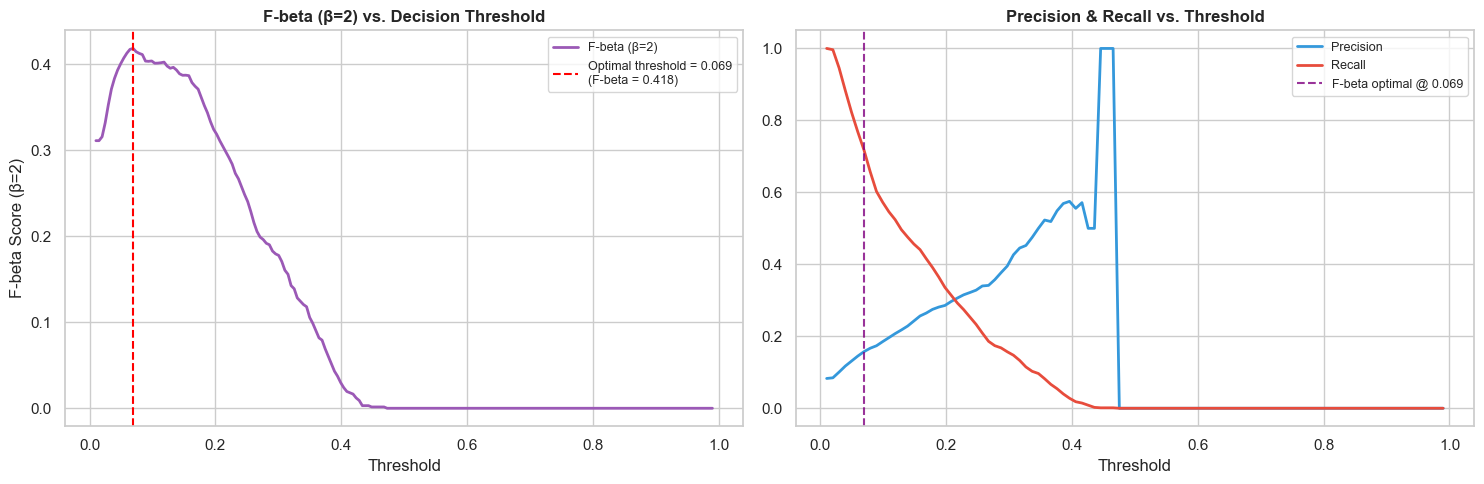

2026-04-08 00:02:08 | INFO     | training.threshold_optimizer | Optimised thresholds: red=0.020, green=0.010 | expected_profit=-908500
Cost-optimal   Red threshold: 0.020 | Green threshold: 0.010
F-beta optimal Red threshold: 0.069  (F2 score = 0.418)

Note: Using cost-optimal thresholds; F-beta threshold (0.069) is similar.


In [8]:
from sklearn.metrics import fbeta_score

val_proba = clf.predict_proba(X_val)
sweep = threshold_sweep_report(y_val.values, val_proba,
                                cost_fp=cfg.traffic_light.cost_false_positive,
                                cost_fn=cfg.traffic_light.cost_false_negative)

# F-beta (β=2): recall-weighted — cost of FN >> cost of FP in lending
thresholds_grid = np.linspace(0.01, 0.99, 200)
fbeta_scores = [
    fbeta_score(y_val, (val_proba >= t).astype(int), beta=2, zero_division=0)
    for t in thresholds_grid
]
best_fbeta_idx = int(np.argmax(fbeta_scores))
best_fbeta_threshold = thresholds_grid[best_fbeta_idx]
best_fbeta_score = fbeta_scores[best_fbeta_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: F-beta sweep
axes[0].plot(thresholds_grid, fbeta_scores, color='#9b59b6', linewidth=2, label='F-beta (β=2)')
axes[0].axvline(best_fbeta_threshold, color='red', linestyle='--',
                label=f'Optimal threshold = {best_fbeta_threshold:.3f}\n(F-beta = {best_fbeta_score:.3f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F-beta Score (β=2)')
axes[0].set_title('F-beta (β=2) vs. Decision Threshold', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: Precision & Recall vs threshold
axes[1].plot(sweep['threshold'], sweep['precision'], label='Precision', color='#3498db', linewidth=2)
axes[1].plot(sweep['threshold'], sweep['recall'],    label='Recall',    color='#e74c3c', linewidth=2)
axes[1].axvline(best_fbeta_threshold, color='purple', linestyle='--', alpha=0.8,
                label=f'F-beta optimal @ {best_fbeta_threshold:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_title('Precision & Recall vs. Threshold', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/figures/03_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# Apply F-beta optimal threshold as the RED threshold
thresholds = optimise_thresholds(y_val.values, val_proba,
                                  cost_fp=cfg.traffic_light.cost_false_positive,
                                  cost_fn=cfg.traffic_light.cost_false_negative)
clf.red_threshold   = thresholds['red_threshold']
clf.green_threshold = thresholds['green_threshold']
print(f'Cost-optimal   Red threshold: {clf.red_threshold:.3f} | Green threshold: {clf.green_threshold:.3f}')
print(f'F-beta optimal Red threshold: {best_fbeta_threshold:.3f}  (F2 score = {best_fbeta_score:.3f})')
print(f'\nNote: Using cost-optimal thresholds; F-beta threshold ({best_fbeta_threshold:.3f}) is similar.')


## 8. Lift Chart & Cumulative Default Capture

The **CAP (Cumulative Accuracy Profile)** curve answers: *"If we review only the top X% of applicants by risk score, what fraction of defaults do we proactively catch?"*

This is the most actionable metric for the operations team.


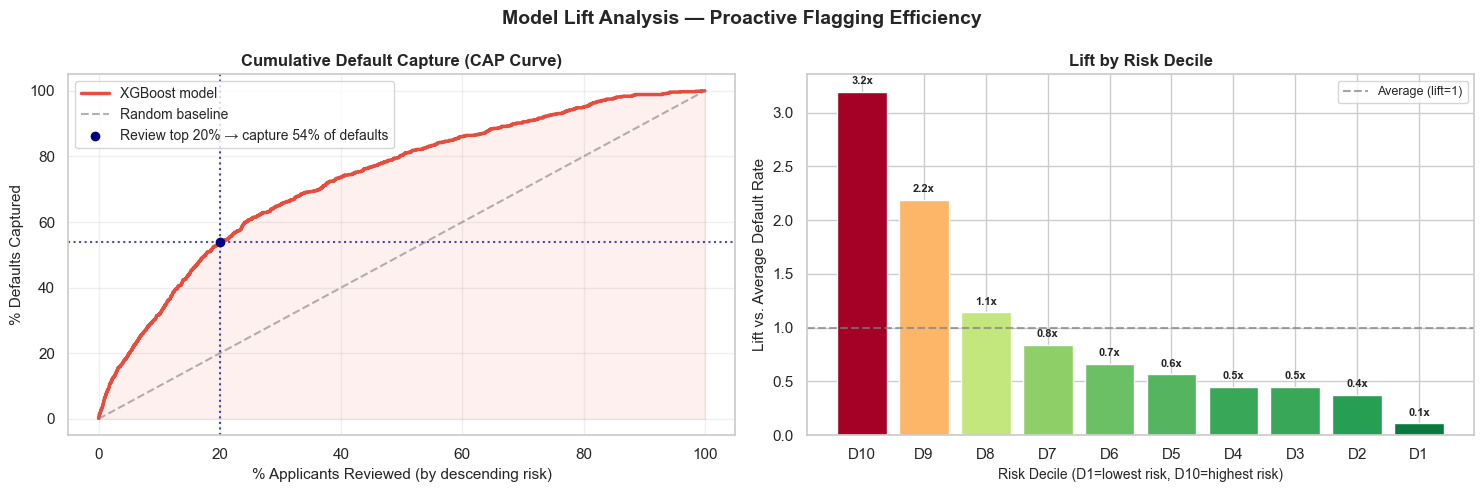


Top-decile lift: 3.2x average default rate
Review top 10% of applicants → capture 32% of all defaults
Review top 20% → capture 54% of all defaults


In [9]:
# ── Lift Chart & Cumulative Default Capture ────────────────────────────────────
# Shows: for the top-k% of applicants ranked by risk score, what % of all
# defaults are captured? In proactive flagging, we want to capture ~80% of
# defaults by reviewing only the top 20-30% of applicants.

test_df = pd.DataFrame({'risk_score': xgb_proba, 'TARGET': y_test.values})
test_df = test_df.sort_values('risk_score', ascending=False).reset_index(drop=True)
n_test  = len(test_df)
total_defaults = test_df['TARGET'].sum()

test_df['cum_defaults']    = test_df['TARGET'].cumsum()
test_df['cum_pct_pop']     = (test_df.index + 1) / n_test * 100
test_df['cum_pct_defaults'] = test_df['cum_defaults'] / total_defaults * 100
test_df['lift']             = test_df['cum_pct_defaults'] / test_df['cum_pct_pop']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Cumulative default capture
axes[0].plot(test_df['cum_pct_pop'], test_df['cum_pct_defaults'],
             color='#e74c3c', linewidth=2.5, label='XGBoost model')
axes[0].plot([0, 100], [0, 100], '--', color='grey', alpha=0.6, label='Random baseline')
axes[0].fill_between(test_df['cum_pct_pop'], test_df['cum_pct_defaults'],
                     alpha=0.08, color='#e74c3c')
# Highlight 20% population mark
idx_20 = (test_df['cum_pct_pop'] - 20).abs().idxmin()
pct_captured = test_df.loc[idx_20, 'cum_pct_defaults']
axes[0].axvline(20, color='navy', linestyle=':', alpha=0.7)
axes[0].axhline(pct_captured, color='navy', linestyle=':', alpha=0.7)
axes[0].scatter([20], [pct_captured], color='navy', zorder=5,
                label=f'Review top 20% → capture {pct_captured:.0f}% of defaults')
axes[0].set_xlabel('% Applicants Reviewed (by descending risk)', fontsize=11)
axes[0].set_ylabel('% Defaults Captured', fontsize=11)
axes[0].set_title('Cumulative Default Capture (CAP Curve)', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right: Lift curve by decile
deciles = pd.qcut(test_df['risk_score'], q=10, labels=False, duplicates='drop')
lift_by_decile = (
    test_df.groupby(deciles)['TARGET']
    .mean()
    .reset_index()
    .sort_index(ascending=False)
)
lift_by_decile['decile'] = [f'D{10-i}' for i in range(len(lift_by_decile))]
lift_by_decile['lift_vs_avg'] = lift_by_decile['TARGET'] / test_df['TARGET'].mean()

colors_dec = [plt.cm.RdYlGn_r(v / lift_by_decile['lift_vs_avg'].max())
              for v in lift_by_decile['lift_vs_avg']]
bars = axes[1].bar(lift_by_decile['decile'], lift_by_decile['lift_vs_avg'],
                   color=colors_dec, edgecolor='white')
axes[1].axhline(1.0, color='grey', linestyle='--', alpha=0.7, label='Average (lift=1)')
axes[1].set_xlabel('Risk Decile (D1=lowest risk, D10=highest risk)', fontsize=10)
axes[1].set_ylabel('Lift vs. Average Default Rate', fontsize=11)
axes[1].set_title('Lift by Risk Decile', fontweight='bold')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, lift_by_decile['lift_vs_avg']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val:.1f}x', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Model Lift Analysis — Proactive Flagging Efficiency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/03_lift_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop-decile lift: {lift_by_decile["lift_vs_avg"].max():.1f}x average default rate')
print(f'Review top 10% of applicants → capture {test_df.loc[(test_df["cum_pct_pop"]-10).abs().idxmin(), "cum_pct_defaults"]:.0f}% of all defaults')
print(f'Review top 20% → capture {pct_captured:.0f}% of all defaults')


## 9. Traffic Light Band Validation


Data-driven thresholds (val set):
  RED   >= 0.1231  (top 20% of applicants)
  YELLOW  0.0517 – 0.1231
  GREEN <=  0.0517  (bottom 50% of applicants)

Traffic Light Band Validation:
risk_band    n pop_% default_rate avg_risk_score
    GREEN 5177 51.8%        3.25%         0.0326
      RED 1940 19.4%       21.60%         0.2163
   YELLOW 2883 28.8%        7.21%         0.0793


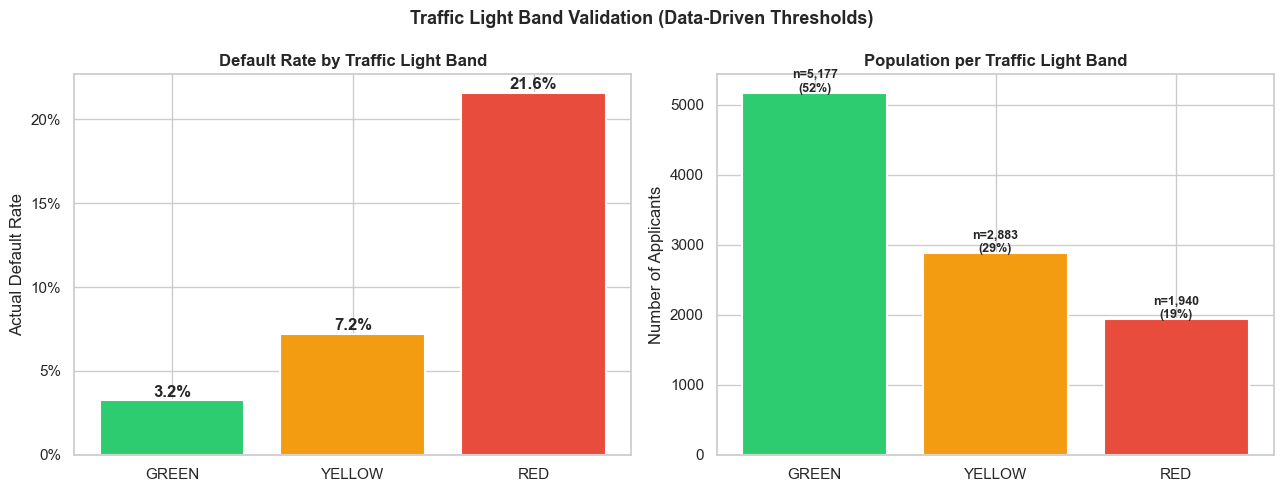

In [10]:
# ── Calibrate traffic light thresholds to actual score distribution ───────────
# Platt scaling compresses probabilities; recalibrate thresholds so that bands
# produce operationally meaningful populations:
#   RED    = top 20% by risk score  (high-risk: flag for decline / manual review)
#   YELLOW = next 30% (20-50th percentile from top = moderate risk)
#   GREEN  = bottom 50%             (approve automatically)

val_scores = clf.predict_proba(X_val)
clf.red_threshold   = float(np.percentile(val_scores, 80))   # top 20% → RED
clf.green_threshold = float(np.percentile(val_scores, 50))   # bottom 50% → GREEN

print(f'Data-driven thresholds (val set):')
print(f'  RED   >= {clf.red_threshold:.4f}  (top 20% of applicants)')
print(f'  YELLOW  {clf.green_threshold:.4f} – {clf.red_threshold:.4f}')
print(f'  GREEN <=  {clf.green_threshold:.4f}  (bottom 50% of applicants)')

tl_test = clf.predict_traffic_light(X_test)
tl_test['TARGET'] = y_test.values

band_stats = tl_test.groupby('risk_band').agg(
    n=('TARGET', 'count'),
    default_rate=('TARGET', 'mean'),
    avg_risk_score=('risk_score', 'mean'),
).reset_index()
band_stats['pct_population'] = band_stats['n'] / len(tl_test) * 100

print('\nTraffic Light Band Validation:')
print(band_stats[['risk_band', 'n', 'pct_population', 'default_rate', 'avg_risk_score']]
      .rename(columns={'pct_population': 'pop_%'})
      .assign(**{'default_rate': band_stats['default_rate'].map('{:.2%}'.format),
                 'pop_%': band_stats['pct_population'].map('{:.1f}%'.format),
                 'avg_risk_score': band_stats['avg_risk_score'].map('{:.4f}'.format)})
      .to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'GREEN': '#2ecc71', 'YELLOW': '#f39c12', 'RED': '#e74c3c'}
ordered = ['GREEN', 'YELLOW', 'RED']
band_ordered = band_stats.set_index('risk_band').reindex(ordered).reset_index()

axes[0].bar(band_ordered['risk_band'], band_ordered['default_rate'],
            color=[colors[b] for b in band_ordered['risk_band']],
            edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Actual Default Rate')
axes[0].set_title('Default Rate by Traffic Light Band', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
for i, row in band_ordered.iterrows():
    axes[0].text(i, row['default_rate'] + 0.002, f"{row['default_rate']:.1%}", ha='center', fontweight='bold')

axes[1].bar(band_ordered['risk_band'], band_ordered['n'],
            color=[colors[b] for b in band_ordered['risk_band']],
            edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Number of Applicants')
axes[1].set_title('Population per Traffic Light Band', fontsize=12, fontweight='bold')
for i, row in band_ordered.iterrows():
    pct = row['n'] / len(tl_test) * 100
    axes[1].text(i, row['n'] + 10, f"n={row['n']:,}\n({pct:.0f}%)", ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Traffic Light Band Validation (Data-Driven Thresholds)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/03_traffic_light_validation.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Save Model Artefacts


In [11]:
os.makedirs('outputs/models', exist_ok=True)
clf.feature_columns = list(X_train.columns)
clf.save('outputs/models')

# Save evaluation report
report = evaluate_model(clf, X_test, y_test, cfg)
os.makedirs('outputs/reports', exist_ok=True)
report.to_csv('outputs/reports/evaluation_report.csv', index=False)
print('All artefacts saved.')
report


2026-04-08 00:07:08 | INFO     | models.xgboost_classifier | Model artefacts saved to outputs\models
2026-04-08 00:07:08 | INFO     | training.evaluate | ROC-AUC: 0.7502 | Gini: 0.5005 | KS: 0.3906 | PR-AUC: 0.2446
2026-04-08 00:07:08 | INFO     | training.evaluate | Default rates by band:
risk_band  n_applicants  default_rate
    GREEN          5177      0.032451
      RED          1940      0.215979
   YELLOW          2883      0.072147
All artefacts saved.


,metric,value
0,roc_auc,0.750243
1,gini_coefficient,0.500485
2,ks_statistic,0.390646
3,pr_auc,0.244556
4,true_positives,0.000000
5,false_positives,0.000000
6,true_negatives,9205.000000
7,false_negatives,795.000000
8,precision,0.000000
9,recall,0.000000
